# 03. Stochastic Simulation: Portfolio Path Projection
Application of Geometric Brownian Motion (GBM) to simulate 1,000 discrete portfolio
trajectories over a 252-trading-day horizon.
This methodology models the range of outcomes congruent with empirical volatility and drift parameters.

In [1]:
import sys; sys.path.insert(0, '..')
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

import pandas as pd
import numpy as np
from dotenv import load_dotenv
load_dotenv()

from src.data.fetcher import StockDataFetcher
from src.portfolio.optimizer import EfficientFrontier
from src.portfolio.monte_carlo import MonteCarloSimulator
from src.portfolio.metrics import (
    TRADING_DAYS_PER_YEAR, RISK_FREE_RATE_ANNUAL, DEFAULT_TICKERS,
    DEFAULT_START_DATE, DEFAULT_END_DATE
)
from src.visualization.plots import plot_price_paths

SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

# Load Data
fetcher = StockDataFetcher(DEFAULT_TICKERS, DEFAULT_START_DATE, DEFAULT_END_DATE)
prices = fetcher.fetch()
log_returns = fetcher.to_log_returns(prices)

# Rebuild EF and get max_sharpe weights
ef = EfficientFrontier(log_returns)
max_sharpe = ef.optimize_max_sharpe()
weights_arr = np.array(list(max_sharpe['weights'].values()))

INFO: Loading from cache: data/cache/4c9b5bec659c75c231b2df3b19a3bf90.csv
INFO: Initialized EF with 10 assets. Date range: 2019-01-02 to 2024-12-30. Annualized return range: [-23.58%, 12.74%]


## 1. Theory: Geometric Brownian Motion

**Stochastic Differential Equation:**
dS = μ · S · dt + σ · S · dW

**Analytical Solution (Itô's Lemma):**
S(t) = S(0) · exp[(μ - σ²/2) · t + σ · W(t)]

The term **(μ - σ²/2)** is the **drift correction** (Itô correction).
Without it, simulated paths would have upward bias. This is a key concept
in quantitative finance (Jensen's inequality).

**Discretized form (used in implementation):**
ln[S(t+1)/S(t)] = (μ - σ²/2) · Δt + σ · √Δt · Z,   Z ~ N(0,1)

## 2. Simulation

In [2]:
sim = MonteCarloSimulator(log_returns, weights_arr, random_seed=42)
paths = sim.simulate_price_paths(n_simulations=1_000, n_days=252, initial_value=100.0)
stats = sim.get_path_statistics(paths)
var_cvar = sim.compute_var_cvar(paths, confidence=0.95)

print(f'Simulated paths:     {paths.shape[0]:,}')
print(f'Simulation horizon:  {paths.shape[1]-1} trading days (1 year)')
print(f'Initial value:       100.0')
print(f'\n--- Results after 1 year ---')
print(f'Median final value:  {var_cvar["median_final"]:.1f}')
print(f'Mean final value:    {var_cvar["mean_final"]:.1f}')
print(f'5th percentile:      {var_cvar["percentile_5"]:.1f}')
print(f'95th percentile:     {var_cvar["percentile_95"]:.1f}')
print(f'VaR (95%, 1-year):   {var_cvar["var_pct"]*100:.2f}%')
print(f'CVaR (95%, 1-year):  {var_cvar["cvar_pct"]*100:.2f}%')

INFO: Simulated 1000 paths for 252 days. Ann. Return: 12.67%, Ann. Vol: 23.69%, Drift: 0.000391


Simulated paths:     1,000
Simulation horizon:  252 trading days (1 year)
Initial value:       100.0

--- Results after 1 year ---
Median final value:  110.1
Mean final value:    113.5
5th percentile:      74.6
95th percentile:     163.8
VaR (95%, 1-year):   25.40%
CVaR (95%, 1-year):  31.49%


## 3. Simulation Paths

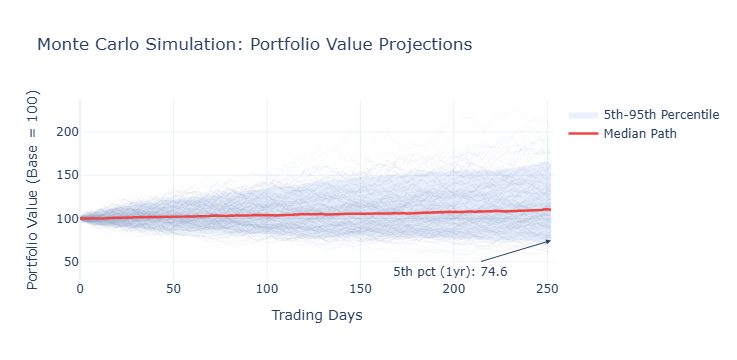

In [3]:
fig = plot_price_paths(paths, stats, var_cvar)
fig.show()

### Interpretation
- Gray lines: Individual simulated paths showing the range of potential outcomes.
- Red line: Median path, representing the 50th percentile outcome.
- Shaded band: 5th to 95th percentile range, capturing the most likely trajectories.

## 4. Final Value Distribution

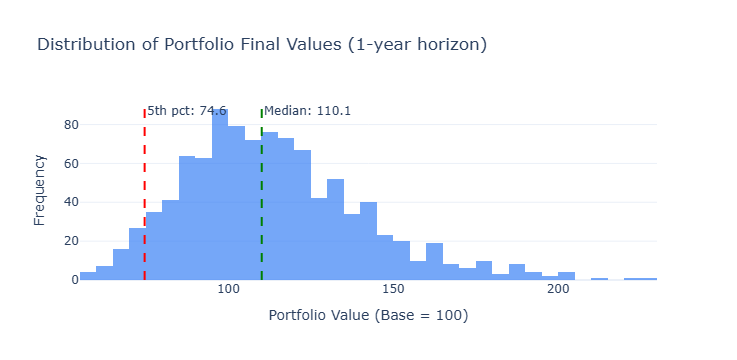

In [4]:
import plotly.graph_objects as go
final_vals = paths[:, -1]
fig = go.Figure()
fig.add_trace(go.Histogram(x=final_vals, nbinsx=50, name='Final Value',
                            marker_color='#3B82F6', opacity=0.7))
fig.add_vline(x=var_cvar['percentile_5'],  line_dash='dash', line_color='red',
              annotation_text=f'5th pct: {var_cvar["percentile_5"]:.1f}')
fig.add_vline(x=var_cvar['median_final'], line_dash='dash', line_color='green',
              annotation_text=f'Median: {var_cvar["median_final"]:.1f}')
fig.update_layout(title='Distribution of Portfolio Final Values (1-year horizon)',
                  xaxis_title='Portfolio Value (Base = 100)',
                  yaxis_title='Frequency', template='plotly_white')
fig.show()

### Interpretation
- The distribution of final values is approximately log-normal.
- The VaR at the 1-year horizon indicates the threshold below which the portfolio value falls only 5% of the time.

## 5. Scenario Analysis

In [5]:
mu_p_annual  = float(np.dot(weights_arr, ef.mean_returns))
sig_p_annual = float(np.sqrt(weights_arr @ ef.cov_matrix @ weights_arr))

scenarios = pd.DataFrame({
    'Scenario': ['Bear (-1σ)', 'Base (Median)', 'Bull (+1σ)'],
    'Assumed Annual Return': [
        f'{(mu_p_annual - sig_p_annual)*100:.1f}%',
        f'{mu_p_annual*100:.1f}%',
        f'{(mu_p_annual + sig_p_annual)*100:.1f}%',
    ],
    'Expected Portfolio Value': [
        f'{100 * np.exp(mu_p_annual - sig_p_annual):.1f}',
        f'{100 * np.exp(mu_p_annual):.1f}',
        f'{100 * np.exp(mu_p_annual + sig_p_annual):.1f}',
    ]
})
scenarios.set_index('Scenario')

,Assumed Annual Return,Expected Portfolio Value
Scenario,,
Bear (-1σ),-11.0%,89.6
Base (Median),12.7%,113.5
Bull (+1σ),36.4%,143.8


## 6. Key Takeaways
- **Optimal Portfolio (Max Sharpe):** 12.67% expected annual return, 23.69% volatility, Sharpe 0.27
- **1-year Projection:** Starting from a base of 100, the median outcome is 110.1 (+10.1%)
- **Downside Risk:** 5% chance the portfolio falls below 74.6 (Base 100) within 1 year (1-year VaR 25.40%)
- **Diversification benefit:** Portfolio Sharpe (0.27) matches the best individual asset Sharpe, showing efficient risk-return balance.
- **Limitation:** GBM assumes constant μ and σ. Real markets have volatility clustering (GARCH effects), fat tails, and regime changes not captured here.